# U-Net — Brain Tumor Segmentation on MRI

Building and training a U-Net convolutional architecture in Keras for pixel-level segmentation of brain tumors in MRI scans, evaluated with the Dice coefficient and monitored against overfitting via training/validation loss curves.

In [2]:
# Mount Google Drive in colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2. Prepare environment

Import libraries

In [3]:
# Import some necessary libraries

import os, glob, numpy as np, cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

And set the paths for images and labels

In [4]:
# Build path to training MRI scans and corresponding masks

DATA_ROOT = "/content/drive/MyDrive/Colab Notebooks/Session 9" # Path to the folder with the dataset
IMG_DIR = os.path.join(DATA_ROOT, "imagesTr") # Path to MRI scans
LB_DIR = os.path.join(DATA_ROOT, "labelsTr") # Path to masks

#3. Load the images

We'll generate a data loader and we'll load the images and split them into train/test sets

In [5]:
# define the data loader
def load_png_data(img_dir, mask_dir, size=(128,128)):

    # Get all paths to the MRI scans and sort them by name
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    # Create empty arrays for the preprocessed data
    imgs_arr, masks_arr = [], []

    for p in imgs:
        # Open MRI scan and its corresponding mask
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(mask_dir, os.path.basename(p)), cv2.IMREAD_GRAYSCALE)

        # Preprocess the data (resize and normalization)
        img = cv2.resize(img, size).astype(np.float32) / 255.0
        mask = (cv2.resize(mask, size) > 127).astype(np.float32)

        # Add them to arrays
        imgs_arr.append(img[..., None])
        masks_arr.append(mask[..., None])
    return np.array(imgs_arr), np.array(masks_arr)

In [6]:
# Load data
X, Y = load_png_data(IMG_DIR, LB_DIR, (128,128))
print("Loaded X, Y shapes:", X.shape, Y.shape)

Loaded X, Y shapes: (50, 128, 128, 1) (50, 128, 128, 1)


In [7]:
# Train test split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Implement the UNET

In [8]:
# This is just to keep our sessions clean, when re-running
import tensorflow.keras.backend as K
K.clear_session()

In [9]:
# Define a simple UNET model in KERAS
def unet_model(input_size=(128,128,1)):
    # Input layer UNet
    inputs = layers.Input(input_size)

    # First Convolution
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    # Second Convolution
    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Third Convolution
    b = layers.Conv2D(64,3,activation='relu',padding='same')(p2)
    b = layers.Conv2D(64,3,activation='relu',padding='same')(b)

    # First Up-Convolution
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2]) # Connection with Second Convolution
    c3 = layers.Conv2D(32,3,activation='relu',padding='same')(u1)
    c3 = layers.Conv2D(32,3,activation='relu',padding='same')(c3)

    # Second Up-Convolution
    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1]) # Connection with First Convolution
    c4 = layers.Conv2D(16,3,activation='relu',padding='same')(u2)
    c4 = layers.Conv2D(16,3,activation='relu',padding='same')(c4)

    # Output layer UNet
    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)
    return models.Model(inputs, outputs)

In [10]:
# Create a model with the function defined previously
model = unet_model()

Compile the model using the Adam optimizer and the binary crossentropy as the loss function.

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_8[0][0]  

 Total params: 117,985 (460.88 KB)

 Trainable params: 117,985 (460.88 KB)

 Non-trainable params: 0 (0.00 B)

#5. Train the UNET

We'll train the model using a batch size of 4 and a small number of epochs (as it is a small dataset). We'll use the validation set that we obtained manually.

In [14]:
# Train the model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=12, batch_size=4)

Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 798ms/step - accuracy: 0.8513 - loss: 0.6500 - val_accuracy: 0.9658 - val_loss: 0.3846
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 502ms/step - accuracy: 0.9756 - loss: 0.2160 - val_accuracy: 0.9658 - val_loss: 0.1001
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 821ms/step - accuracy: 0.9755 - loss: 0.0759 - val_accuracy: 0.9658 - val_loss: 0.0856
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 501ms/step - accuracy: 0.9724 - loss: 0.0723 - val_accuracy: 0.9658 - val_loss: 0.0757
Epoch 5/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 645ms/step - accuracy: 0.9715 - loss: 0.0670 - val_accuracy: 0.9658 - val_loss: 0.0693
Epoch 6/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 490ms/step - accuracy: 0.9722 - loss: 0.0590 - val_accuracy: 0.9658 - val_loss: 0.0630
Epoch 7/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 746ms/step - accuracy: 0.9743 - loss: 0.0500 - val_accuracy: 0.9658 - val_loss: 0.0598
Epoch 8/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 524ms/step - accuracy: 0.9702 - loss: 0.0528 - val_accuracy: 0.

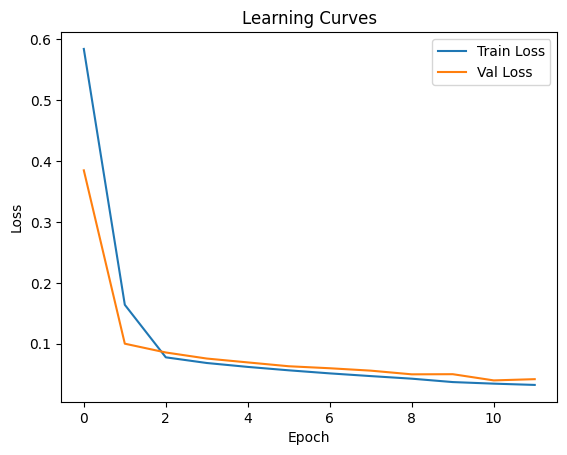

In [15]:
# Plot the curves (use the code that was given in the prev session)
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves')
plt.show()

# 6. Do some predictions

Predict and compute dice per-sample

In [16]:
# Function to calculate the dice coefficient between labels and predictions
import numpy as np
def dice_coef_np(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    inter = np.sum(y_true_f * y_pred_f)
    return (2*inter + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

# Use the trained UNet to predict masks
Y_pred = model.predict(X_val)
Y_pred_bin = (Y_pred > 0.5).astype(np.float32)

# Calculate dice scores for each predicted mask, comparing it to the known mask
dice_scores = []
for yt, yp in zip(Y_val, Y_pred_bin):
    dice_scores.append(dice_coef_np(yt, yp))

# Show metrics
import statistics
print("Per-sample Dice (first 10):", dice_scores[:10])
print("Mean Dice:", statistics.mean(dice_scores), "Std:", statistics.pstdev(dice_scores))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
Per-sample Dice (first 10): [np.float32(0.72678334), np.float32(0.848), np.float32(0.8668555), np.float32(0.7079646), np.float32(0.6875544), np.float32(0.66182226), np.float32(0.815235), np.float32(0.8358933), np.float32(0.8391994), np.float32(0.7033493)]
Mean Dice: 0.7692657 Std: 0.07436018482286545


Visualize a few predictions

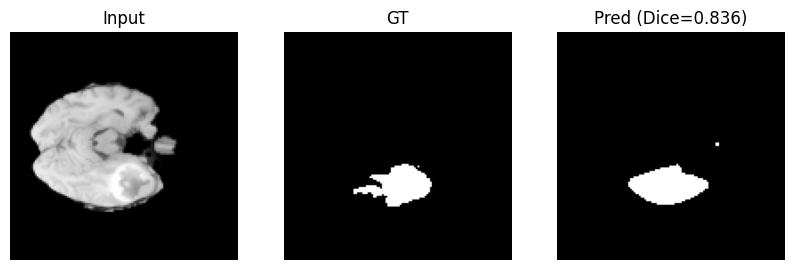

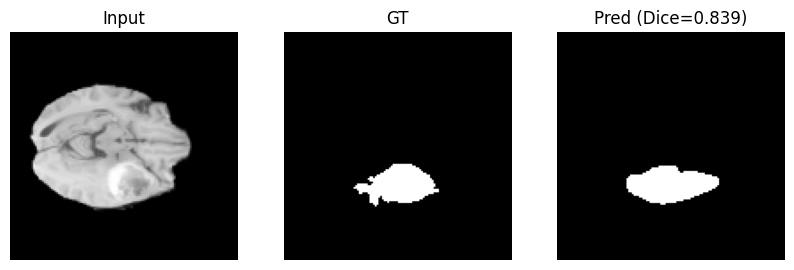

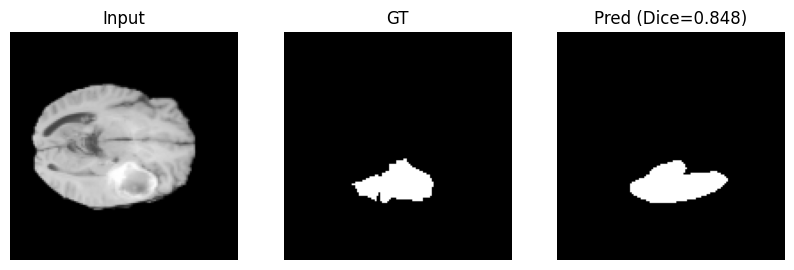

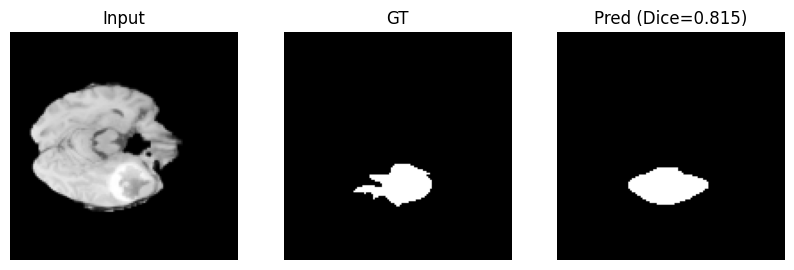

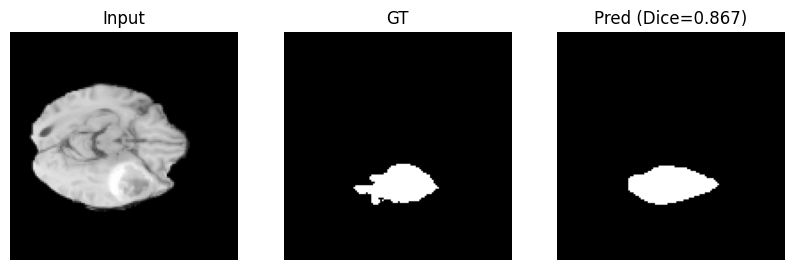

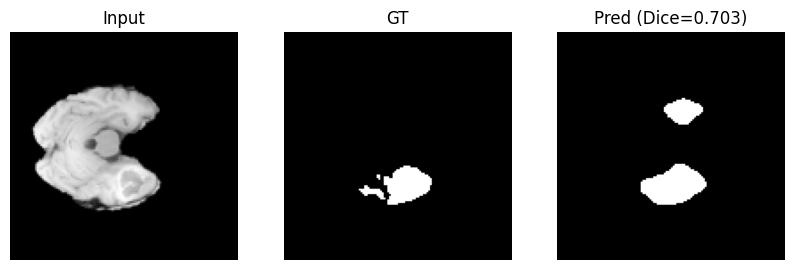

In [17]:
import matplotlib.pyplot as plt, random

# Select random indices from the predictions of the previous cell
idxs = list(range(len(X_val)))
random.shuffle(idxs)

# Plot 6 plots
for i in idxs[:6]:
    # Make plot figure
    plt.figure(figsize=(10,4))

    # Show MRI scan
    plt.subplot(1,3,1); plt.imshow(X_val[i].squeeze(), cmap='gray'); plt.title('Input'); plt.axis('off')

    # Show known mask
    plt.subplot(1,3,2); plt.imshow(Y_val[i].squeeze(), cmap='gray'); plt.title('GT'); plt.axis('off')

    # Show predicted mask with dice score
    plt.subplot(1,3,3); plt.imshow(Y_pred_bin[i].squeeze(), cmap='gray'); plt.title(f'Pred (Dice={dice_scores[i]:.3f})'); plt.axis('off')
    plt.show()


## Checking sensitivity to training length

To check whether the model was genuinely converging rather than just running out of epochs, I reran training with a different batch size and number of epochs and compared the resulting learning curves.

In [18]:
# Train the model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=8)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 990ms/step - accuracy: 0.9851 - loss: 0.0343 - val_accuracy: 0.9798 - val_loss: 0.0435
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9852 - loss: 0.0323 - val_accuracy: 0.9816 - val_loss: 0.0407
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9875 - loss: 0.0287 - val_accuracy: 0.9851 - val_loss: 0.0363
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9885 - loss: 0.0270 - val_accuracy: 0.9839 - val_loss: 0.0363
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 998ms/step - accuracy: 0.9902 - loss: 0.0234 - val_accuracy: 0.9870 - val_loss: 0.0312
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9905 - loss: 0.0231 - val_accuracy: 0.9859 - val_loss: 0.0331
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9901 - loss: 0.0228 - val_accuracy: 0.9834 - val_loss: 0.0366
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9900 - loss: 0.0233 - val_accuracy: 0.9888 - val_loss: 0.0273
Epoch 9/20

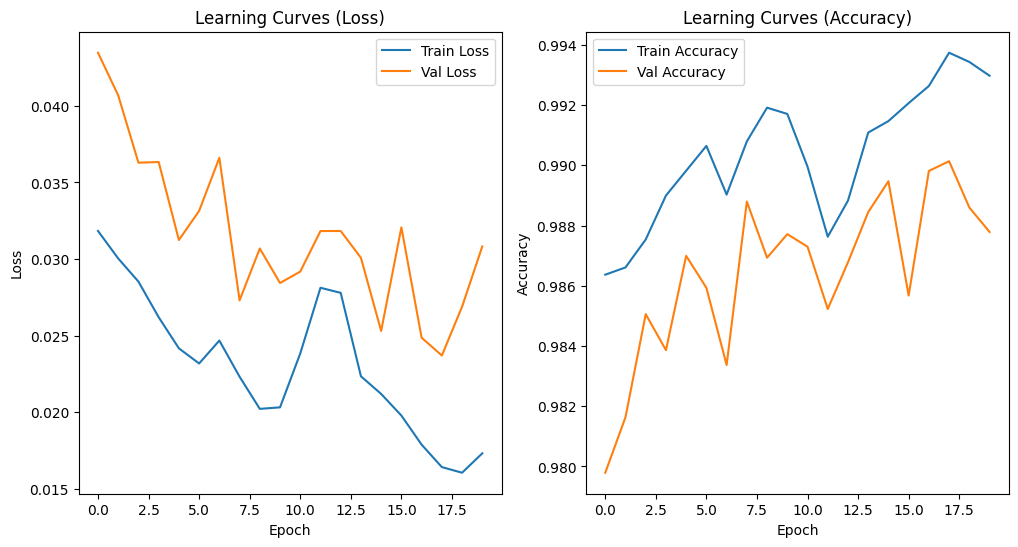

In [19]:
# Plot the curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves (Loss)')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curves (Accuracy)')

plt.show()

## Comment on the differences in the learning curves

In summary, increasing the number of epochs allowed the model to further reduce the training loss and increase training accuracy. However, the gap between training and validation performance towards the end of training suggests that the model is starting to overfit. This indicates that for this dataset and model architecture, training for 20 epochs with a batch size of 8 might be too long, and early stopping or regularization techniques could be beneficial to prevent overfitting.